# Tortuosity via FDM diffusion solver

This example computes the diffusional tortuosity of a synthetic porous medium using the finite difference method (FDM) solver.

In [1]:
import porespy as ps
import matplotlib.pyplot as plt
import poromics

## Generate a porous medium image

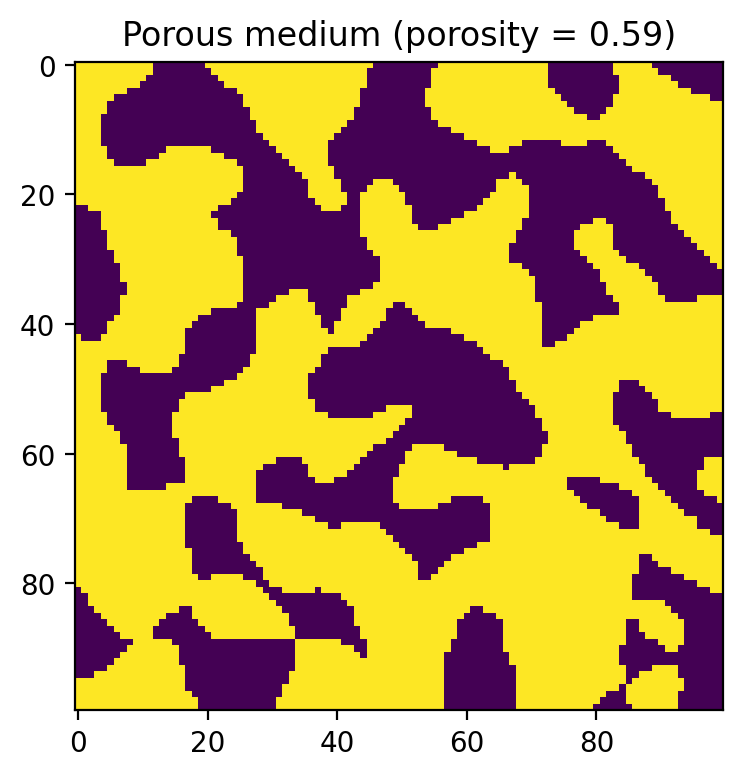

In [2]:
im = ps.generators.blobs(shape=[100, 100, 1], porosity=0.6, blobiness=0.5, seed=42)

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(im[:, :, 0], cmap="viridis", interpolation="nearest")
ax.set_title(f"Porous medium (porosity = {im.mean():.2f})")
plt.tight_layout()

## Compute tortuosity

In [3]:
result = poromics.tortuosity_fd(im, axis=1, rtol=1e-5)
print(result)
print(f"Tortuosity: {result.tau:.4f}")
print(f"Effective diffusivity (D_eff/D_0): {result.D_eff:.6f}")
print(f"Formation factor: {result.formation_factor:.4f}")

2026-03-09 01:25:36.82 | WARNING  | poromics._metrics:tortuosity_fd:218 - Trimmed 972 non-percolating pore voxels from the image.


TortuosityResult(tau=4.2636, D_eff=0.116124, axis=1)
Tortuosity: 4.2636
Effective diffusivity (D_eff/D_0): 0.116124
Formation factor: 8.6115


## Visualize the concentration field

The steady-state concentration field shows how species diffuses through the tortuous pore network.

(<Figure size 750x400 with 4 Axes>,
 array([<Axes: title={'center': 'Pore structure'}>,
        <Axes: title={'center': 'Concentration field'}>], dtype=object))

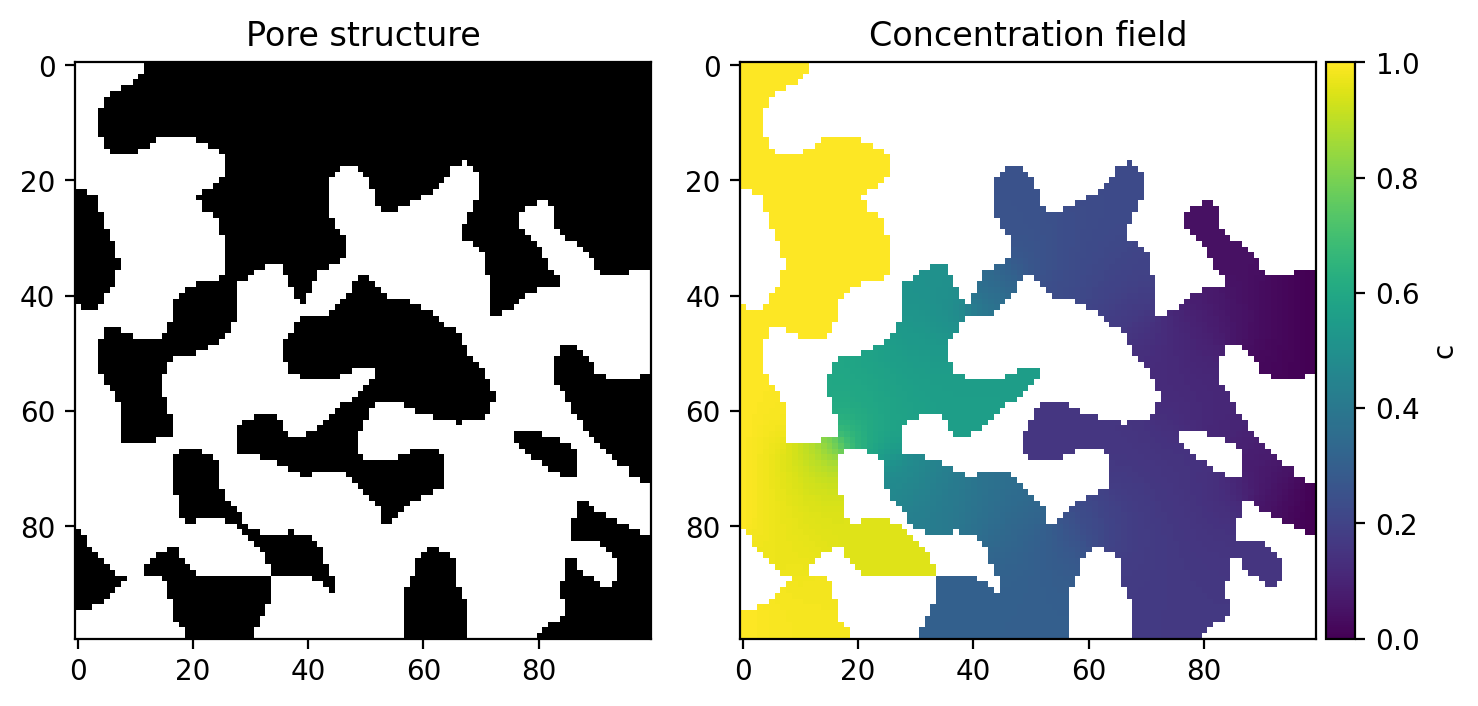

In [4]:
result.plot_concentration(z=0)